This notebook examines 9 months of my workout data exported from Strong, tracking consistency and strength progression in my fitness journey. I cleaned the data by removing rest timers and non-working sets, then found features like volume and used the Epley formula to find my estimate one rep max. This version does not contain body weight as I was not consistent nor organized enough with tracking that data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("data/strong_workouts.csv")


,Date,Workout Name,Duration,Exercise Name,Set Order,Weight,Reps,Distance,Seconds,Notes,Workout Notes,RPE
0,2025-08-26 10:44:22,Morning Workout,28m,Seated Overhead Press (Dumbbell),1,17.5,10.0,0.0,0.0,NaN,NaN,NaN
1,2025-08-26 10:44:22,Morning Workout,28m,Seated Overhead Press (Dumbbell),Rest Timer,0.0,0.0,0.0,120.0,NaN,NaN,NaN
2,2025-08-26 10:44:22,Morning Workout,28m,Seated Overhead Press (Dumbbell),2,17.5,10.0,0.0,0.0,NaN,NaN,NaN
3,2025-08-26 10:44:22,Morning Workout,28m,Seated Overhead Press (Dumbbell),Rest Timer,0.0,0.0,0.0,120.0,NaN,NaN,NaN
4,2025-08-26 10:44:22,Morning Workout,28m,Seated Overhead Press (Dumbbell),3,17.5,10.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5016,2026-05-09 15:19:09,Back and Biceps (Pull),30m,Hammer Curl (Dumbbell),Rest Timer,0.0,0.0,0.0,120.0,NaN,NaN,NaN
5017,2026-05-09 15:19:09,Back and Biceps (Pull),30m,Hammer Curl (Dumbbell),3,20.0,12.0,0.0,0.0,NaN,NaN,NaN
5018,2026-05-09 15:19:09,Back and Biceps (Pull),30m,Hammer Curl (Dumbbell),Rest Timer,0.0,0.0,0.0,120.0,NaN,NaN,NaN
5019,2026-05-09 15:19:09,Back and Biceps (Pull),30m,Hammer Curl (Dumbbell),4,20.0,12.0,0.0,0.0,NaN,NaN,NaN


In [24]:
clean_data = data.copy()
clean_data = clean_data.dropna(axis=1)

clean_data = clean_data[clean_data["Set Order"].str.fullmatch(r"\d+")].copy()

clean_data["Date"] = pd.to_datetime(clean_data["Date"])
clean_data["Weight"] = pd.to_numeric(clean_data["Weight"], errors="coerce")

clean_data["Reps"] = pd.to_numeric(clean_data["Reps"], errors="coerce")
clean_data["Volume"] = clean_data["Reps"] * clean_data["Weight"]
clean_data["Estimate_1RM"] = clean_data["Weight"] * (1 + clean_data["Reps"]/30)

clean_data["Week_Start"] = clean_data["Date"].dt.to_period("W").apply(lambda x: x.start_time)
clean_data

,Date,Workout Name,Duration,Exercise Name,Set Order,Weight,Reps,Distance,Seconds,Volume,Estimate_1RM,Week_Start
0,2025-08-26 10:44:22,Morning Workout,28m,Seated Overhead Press (Dumbbell),1,17.5,10.0,0.0,0.0,175.0,23.333333,2025-08-25
2,2025-08-26 10:44:22,Morning Workout,28m,Seated Overhead Press (Dumbbell),2,17.5,10.0,0.0,0.0,175.0,23.333333,2025-08-25
4,2025-08-26 10:44:22,Morning Workout,28m,Seated Overhead Press (Dumbbell),3,17.5,10.0,0.0,0.0,175.0,23.333333,2025-08-25
6,2025-08-26 10:44:22,Morning Workout,28m,Bench Press (Dumbbell),1,17.5,10.0,0.0,0.0,175.0,23.333333,2025-08-25
8,2025-08-26 10:44:22,Morning Workout,28m,Bench Press (Dumbbell),2,17.5,10.0,0.0,0.0,175.0,23.333333,2025-08-25
...,...,...,...,...,...,...,...,...,...,...,...,...
5011,2026-05-09 15:19:09,Back and Biceps (Pull),30m,Bicep Curl (Dumbbell),3,35.0,8.0,0.0,0.0,280.0,44.333333,2026-05-04
5013,2026-05-09 15:19:09,Back and Biceps (Pull),30m,Hammer Curl (Dumbbell),1,20.0,12.0,0.0,0.0,240.0,28.000000,2026-05-04
5015,2026-05-09 15:19:09,Back and Biceps (Pull),30m,Hammer Curl (Dumbbell),2,20.0,12.0,0.0,0.0,240.0,28.000000,2026-05-04
5017,2026-05-09 15:19:09,Back and Biceps (Pull),30m,Hammer Curl (Dumbbell),3,20.0,12.0,0.0,0.0,240.0,28.000000,2026-05-04


<Axes: xlabel='Week_Start'>

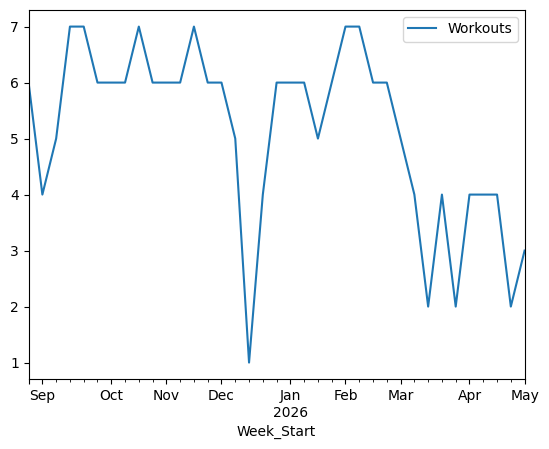

In [42]:
workouts_per_week = clean_data.groupby("Week_Start")["Date"].nunique().reset_index(name="Workouts")
workouts_per_week.plot(kind="line", x="Week_Start", y="Workouts")

In [ ]:
daily_strength = clean_data.groupby(["Date", "Exercise Name"])["Estimate_1RM"].max().reset_index()

daily_strength


,Date,Exercise Name,Estimate_1RM
0,2025-08-26 10:44:22,Bench Press (Dumbbell),23.333333
1,2025-08-26 10:44:22,Bicep Curl (Dumbbell),24.500000
2,2025-08-26 10:44:22,Lateral Raise (Dumbbell),9.500000
3,2025-08-26 10:44:22,Plank,0.000000
4,2025-08-26 10:44:22,Seated Overhead Press (Dumbbell),23.333333
...,...,...,...
660,2026-05-08 15:33:04,Triceps Extension (Dumbbell),26.666667
661,2026-05-08 15:33:04,Triceps Pushdown (Cable - Straight Bar),132.000000
662,2026-05-09 15:19:09,Bicep Curl (Dumbbell),44.333333
663,2026-05-09 15:19:09,Hammer Curl (Dumbbell),28.000000


<Axes: xlabel='Date'>

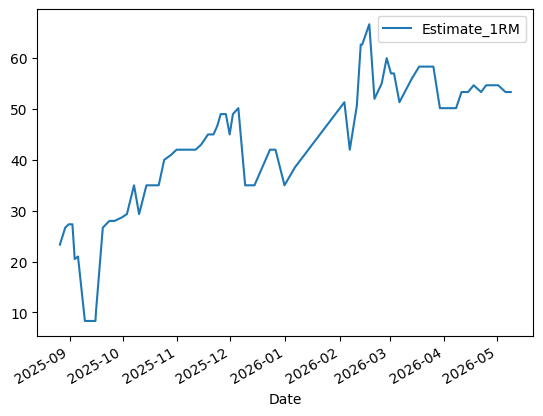

In [44]:
#TEST CELL FOR DAILY STRENGTH
exercise = "Bench Press (Dumbbell)" 

bench_trend = daily_strength[daily_strength["Exercise Name"] == exercise]

bench_trend.plot(kind="line", x="Date", y="Estimate_1RM")

<Axes: xlabel='Week_Start'>

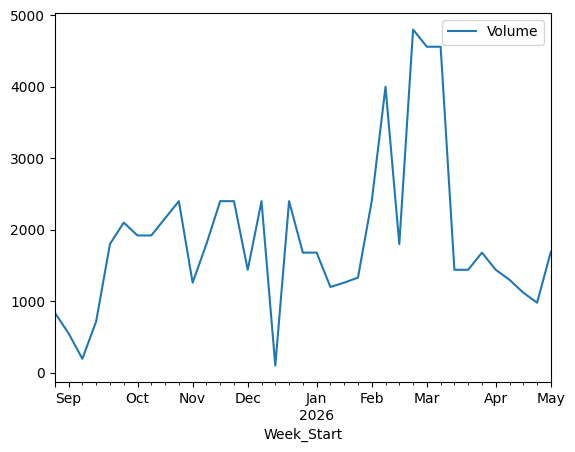

In [48]:
weekly_volume = clean_data.groupby("Week_Start")["Volume"].max().reset_index()
weekly_volume.plot(kind="line", x="Week_Start", y="Volume")

As can be seen here, dumbbell bench did not stay consistent and plummeted. I attribute this to laziness as well as eating less due to my cut.

In [41]:
personal_records = clean_data.groupby("Exercise Name").agg({
    "Estimate_1RM": ["max", "mean"],
    "Weight": "max",
    "Reps": "max",
    "Volume": "sum",
    "Date": ["min", "max"]
                                                            
                                                            }).reset_index()
personal_records

Exercise Name Estimate_1RM             Weight  \
                                                     max        mean    max   
0                     Bench Press (Barbell)   146.666667  124.782407  110.0   
1                    Bench Press (Dumbbell)    66.666667   39.479710   45.0   
2                     Bicep Curl (Dumbbell)    73.333333   37.037464   40.0   
3                          Chest Fly (Band)    13.333333   13.333333   10.0   
4                     Chest Press (Machine)   186.333333  157.925926  150.0   
5                                    Crunch     0.000000    0.000000    0.0   
6                        Deadlift (Barbell)    98.000000   85.595238   70.0   
7                  Glute Kickback (Machine)   121.333333  109.777778   70.0   
8                       Hammer Curl (Cable)    66.666667   66.666667   50.0   
9                    Hammer Curl (Dumbbell)    28.000000   28.000000   20.0   
10                  Hip Thrust (Bodyweight)     0.000000    0.000000    0.0   
11                   Incline Row (Dumbbell)    23.333333   19.600000   17.5   
12                     Lat Pulldown (Cable)   177.666667  129.828598  150.0   
13                   Lat Pulldown (Machine)   126.000000  126.000000   90.0   
14                     Lateral Raise (Band)    13.333333   13.333333   10.0   
15                 Lateral Raise (Dumbbell)    29.666667   17.142803   20.0   
16                         Lunge (Dumbbell)    35.000000   20.956710   25.0   
17                Overhead Press (Dumbbell)    52.500000   32.886964   35.0   
18                                    Plank     0.000000    0.000000    0.0   
19                                  Pull Up     0.000000    0.000000    0.0   
20                       Pull Up (Assisted)    58.333333   57.391304   50.0   
21                                  Push Up     0.000000    0.000000    0.0   
22                  Reverse Curl (Dumbbell)    22.666667   16.758065   15.0   
23                   Reverse Fly (Dumbbell)    12.666667   10.777778   10.0   
24             Romanian Deadlift (Dumbbell)    53.000000   32.624561   30.0   
25               Seated Leg Press (Machine)   400.000000  241.955128  240.0   
26         Seated Overhead Press (Dumbbell)    26.666667   22.625000   20.0   
27                       Seated Row (Cable)   140.000000  108.003145  100.0   
28                     Seated Row (Machine)    98.000000   95.666667   70.0   
29                 Shoulder Press (Machine)   126.000000  102.444444   90.0   
30                       Squat (Bodyweight)     0.000000    0.000000    0.0   
31                         Squat (Dumbbell)    50.000000   27.014323   32.5   
32             Triceps Extension (Dumbbell)    26.666667   19.614035   20.0   
33  Triceps Pushdown (Cable - Straight Bar)   218.400000  134.736893  170.0   
34                                  Walking     0.000000    0.000000    0.0   

    Reps    Volume                Date                      
     max       sum                 min                 max  
0   20.0   73330.0 2025-12-07 11:27:16 2026-02-08 12:06:22  
1   30.0   80935.0 2025-08-26 10:44:22 2026-05-08 15:33:04  
2   25.0   70688.0 2025-08-26 10:44:22 2026-05-09 15:19:09  
3   10.0     300.0 2025-12-17 16:40:27 2025-12-17 16:40:27  
4   15.0   12340.0 2025-10-17 11:37:38 2026-05-08 15:33:04  
5   20.0       0.0 2025-08-27 18:09:55 2025-12-29 17:21:54  
6   12.0   18500.0 2025-11-29 09:08:47 2026-02-11 13:14:59  
7   24.0   12540.0 2026-02-19 11:52:07 2026-02-26 15:20:40  
8   10.0    1500.0 2025-10-08 11:47:13 2025-10-08 11:47:13  
9   12.0     960.0 2026-05-09 15:19:09 2026-05-09 15:19:09  
10  38.0       0.0 2026-02-08 19:58:24 2026-02-22 18:39:32  
11  12.0     765.0 2025-08-27 18:09:55 2025-09-24 10:44:27  
12  20.0  174595.0 2025-08-30 11:45:20 2026-05-09 15:19:09  
13  12.0    7560.0 2025-10-08 11:47:13 2026-03-18 19:17:31  
14  10.0     300.0 2025-12-17 16:40:27 2025-12-17 16:40:27  
15  59.0   35337.5 2025-08-26 10:44:22 2026-05-08 15:33:04  
16  16.0